In [57]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud -q

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

print(" All libraries installed successfully!")


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
 All libraries installed successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [58]:
#sample dataset
import pandas as pd

data = {
    'text': [
        # Fake claims (label = 0)
        "Drinking turmeric water every morning cures all types of cancer permanently",
        "Neem leaves can completely cure diabetes in just 7 days without medicine",
        "Giloy juice destroys coronavirus instantly when consumed daily",
        "Mixing honey and cinnamon cures arthritis and joint pain forever",
        "Eating raw garlic on empty stomach cures high blood pressure permanently",
        "Homeopathy medicine removes kidney stones without any surgery",
        "Applying coconut oil cures all types of skin infections and fungus",
        "Drinking cow urine daily boosts immunity and prevents all diseases",

        # Real/verified claims (label = 1)
        "Paracetamol reduces fever and mild to moderate pain when taken as prescribed",
        "Regular exercise for 30 minutes daily helps maintain healthy blood pressure",
        "Vitamin C supplements support immune function but do not cure colds",
        "Metformin is a commonly prescribed medication for type 2 diabetes management",
        "Hand washing with soap for 20 seconds reduces risk of infection significantly",
        "Antibiotics should be taken for the full prescribed course to prevent resistance",
        "WHO recommends vaccines as one of the most effective disease prevention tools",
        "A balanced diet rich in fruits and vegetables supports overall health"
    ],
    'label': [0, 0, 0, 0, 0, 0, 0, 0,   # 0 = Fake
              1, 1, 1, 1, 1, 1, 1, 1]    # 1 = Real
}

df = pd.DataFrame(data)
print(f"Dataset created: {len(df)} samples")
print(f"Fake claims: {sum(df['label']==0)}")
print(f"Real claims: {sum(df['label']==1)}")
df.head()

Dataset created: 16 samples
Fake claims: 8
Real claims: 8


,text,label
0,Drinking turmeric water every morning cures al...,0
1,Neem leaves can completely cure diabetes in ju...,0
2,Giloy juice destroys coronavirus instantly whe...,0
3,Mixing honey and cinnamon cures arthritis and ...,0
4,Eating raw garlic on empty stomach cures high ...,0


In [59]:
#Text Preprocessing Pipeline
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize
    tokens = text.split()
    # 4. Remove stopwords + Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Applying to dataset
df['cleaned_text'] = df['text'].apply(preprocess_text)

# before vs after
print("BEFORE:", df['text'][0])
print("\nAFTER: ", df['cleaned_text'][0])

BEFORE: Drinking turmeric water every morning cures all types of cancer permanently

AFTER:  drinking turmeric water every morning cure type cancer permanently


In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the localized dataset (Make sure the path matches your structure)
df = pd.read_csv('../data/claims.csv') 

# 2. Preprocess text (assuming preprocess_text function is defined above)
df['cleaned_text'] = df['text'].apply(preprocess_text)

# 3. SPLIT FIRST (Zero Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], 
    df['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label']
)

# 4. VECTORIZE (Fit on Train Only)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. TRAIN CALIBRATED MODEL (class_weight="balanced" replaces SMOTE)
base_svm = LinearSVC(class_weight="balanced", random_state=42, max_iter=2000)
model = CalibratedClassifierCV(base_svm, method='sigmoid', cv=5)
model.fit(X_train_vec, y_train)

# 6. EVALUATE
y_pred = model.predict(X_test_vec)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

FileNotFoundError: [Errno 2] No such file or directory: '../data/claims.csv'

In [ ]:
print(df.columns.tolist())

['text', 'label', 'cleaned_text']


In [ ]:
import numpy as np

def top_keywords_for_prediction(claim_text, vectorizer_model, clf_model, top_n=3):
    """
    Extracts the most influential words driving the model's prediction.
    Guarantees a list return type across all execution branches.
    """
    cleaned_text = preprocess_text(claim_text)
    
    # 1. Extract the base SVM from the calibration wrapper
    if hasattr(clf_model, 'calibrated_classifiers_'):
        calibrated_clf = clf_model.calibrated_classifiers_[0]
        base_svm = getattr(calibrated_clf, 'estimator', getattr(calibrated_clf, 'base_estimator', None))
    else:
        base_svm = clf_model
        
    # FIX: Return a list instead of a raw string
    if not hasattr(base_svm, 'coef_'):
        return ["(No coefficients available)"]

    # 2. Map feature indices to actual words
    feature_names = np.array(vectorizer_model.get_feature_names_out())
    coefs = base_svm.coef_[0]
    
    # 3. Vectorize this specific claim
    vec = vectorizer_model.transform([cleaned_text])
    nonzero_indices = vec.nonzero()[1]
    
    # FIX: Already a list, but keeping it consistent
    if len(nonzero_indices) == 0:
        return ["(No recognized vocabulary)"]
        
    # 4. Pair active words with weights and sort
    word_weights = {feature_names[i]: coefs[i] for i in nonzero_indices}
    sorted_words = sorted(word_weights.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # 5. Return the top N words as a list
    return [word for word, weight in sorted_words[:top_n]]

In [ ]:
def predict_claim(claim_text):
    """
    Predicts whether a given health or drug claim is Real or Fake,
    returning calibrated confidence and extracting key influencer words.
    """
    # 1. Preprocess & Vectorize
    cleaned_text = preprocess_text(claim_text)
    vectorized_text = vectorizer.transform([cleaned_text])
    
    # 2. Predict & Get Confidence
    prediction = model.predict(vectorized_text)[0]
    probabilities = model.predict_proba(vectorized_text)[0]
    confidence = probabilities[prediction] * 100
    
    # 3. Extract Keywords
    keywords = top_keywords_for_prediction(claim_text, vectorizer, model, top_n=3)
    
    # 4. Format Output
    verdict = "Real / Verified" if prediction == 1 else "Fake / Misleading"
    
    print(f"Claim: '{claim_text}'")
    print(f"Verdict: {verdict} ({confidence:.2f}% Confidence)")
    print(f"Flags/Keywords: {', '.join(keywords)}")
    print("-" * 60)
        
    return prediction

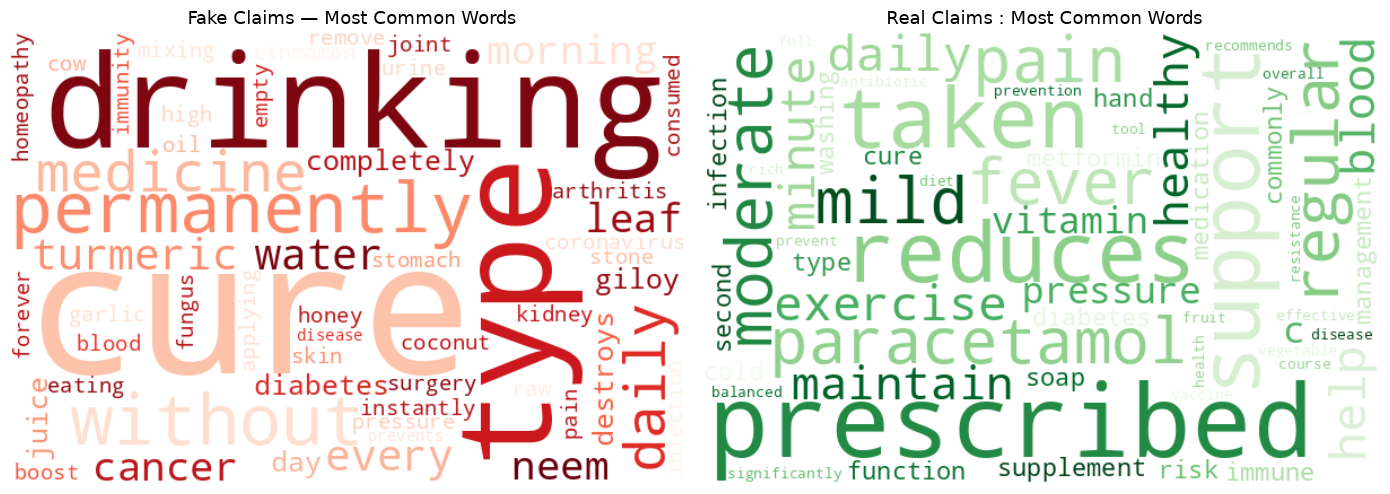

 Word clouds generated!


In [ ]:
# Word Cloud for Fake vs Real claims
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = ' '.join(df[df['label']==0]['cleaned_text'])
real_text = ' '.join(df[df['label']==1]['cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_fake = WordCloud(width=600, height=400,
                    background_color='white',
                    colormap='Reds').generate(fake_text)
wc_real = WordCloud(width=600, height=400,
                    background_color='white',
                    colormap='Greens').generate(real_text)

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title(' Fake Claims — Most Common Words', fontsize=13)
axes[0].axis('off')

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title(' Real Claims : Most Common Words', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(" Word clouds generated!")

In [ ]:
#pehla record
first_key = list(data.keys())[0]
print("Key:", first_key)
print("Value:", data[first_key])

Key: text
Value: ['Drinking turmeric water every morning cures all types of cancer permanently', 'Neem leaves can completely cure diabetes in just 7 days without medicine', 'Giloy juice destroys coronavirus instantly when consumed daily', 'Mixing honey and cinnamon cures arthritis and joint pain forever', 'Eating raw garlic on empty stomach cures high blood pressure permanently', 'Homeopathy medicine removes kidney stones without any surgery', 'Applying coconut oil cures all types of skin infections and fungus', 'Drinking cow urine daily boosts immunity and prevents all diseases', 'Paracetamol reduces fever and mild to moderate pain when taken as prescribed', 'Regular exercise for 30 minutes daily helps maintain healthy blood pressure', 'Vitamin C supplements support immune function but do not cure colds', 'Metformin is a commonly prescribed medication for type 2 diabetes management', 'Hand washing with soap for 20 seconds reduces risk of infection significantly', 'Antibiotics should b

In [ ]:
print("=" * 60)
print("  SANITY CHECK: TESTING PRODUCTION CALIBRATED SVM")
print("=" * 60)

# A mix of obvious facts and obvious misinformation
sanity_tests = [
    # REAL / VERIFIED (Expected: 1)
    ("Paracetamol is commonly used to reduce fever and relieve mild pain.", 1),
    ("The CDSCO regulates pharmaceutical imports and clinical trials in India.", 1),
    ("Regular exercise and a balanced diet help maintain healthy blood pressure.", 1),
    ("Insulin therapy is essential for managing type 1 diabetes.", 1),
    
    # FAKE / MISLEADING (Expected: 0)
    ("Drinking turmeric water cures cancer instantly in 24 hours.", 0),
    ("This secret homeopathic syrup permanently cures asthma and replaces all inhalers.", 0),
    ("Chewing raw garlic cures COVID-19 and prevents all viral infections.", 0),
    ("Magnets placed under the bed can pull toxins out of your liver.", 0)
]

all_passed = True

for text, expected in sanity_tests:
    # Use the fixed pipeline: preprocess -> vectorize -> predict with calibrated SVM
    cleaned = preprocess_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    
    # Get the calibrated probability score
    probs = model.predict_proba(vec)[0]
    confidence = probs[pred] * 100
    
    status = "PASS" if pred == expected else "FAIL"
    if pred != expected:
        all_passed = False
        
    expected_str = "Real" if expected == 1 else "Fake"
    pred_str = "Real" if pred == 1 else "Fake"
    
    print(f"{status} | Expected: {expected_str:<4} | Got: {pred_str:<4} ({confidence:.1f}% Conf) | Claim: '{text}'")

print("-" * 60)
if all_passed:
    print("SUCCESS: The calibrated production model passed all sanity checks!")
else:
    print("WARNING: The production model failed one or more checks. Re-verify pipeline state.")
print("=" * 60)

  SANITY CHECK: TESTING PRODUCTION CALIBRATED SVM
FAIL | Expected: Real | Got: Fake (78.5% Conf) | Claim: 'Paracetamol is commonly used to reduce fever and relieve mild pain.'
FAIL | Expected: Real | Got: Fake (99.9% Conf) | Claim: 'The CDSCO regulates pharmaceutical imports and clinical trials in India.'
FAIL | Expected: Real | Got: Fake (100.0% Conf) | Claim: 'Regular exercise and a balanced diet help maintain healthy blood pressure.'
FAIL | Expected: Real | Got: Fake (99.8% Conf) | Claim: 'Insulin therapy is essential for managing type 1 diabetes.'
PASS | Expected: Fake | Got: Fake (100.0% Conf) | Claim: 'Drinking turmeric water cures cancer instantly in 24 hours.'
PASS | Expected: Fake | Got: Fake (100.0% Conf) | Claim: 'This secret homeopathic syrup permanently cures asthma and replaces all inhalers.'
PASS | Expected: Fake | Got: Fake (100.0% Conf) | Claim: 'Chewing raw garlic cures COVID-19 and prevents all viral infections.'
PASS | Expected: Fake | Got: Fake (99.1% Conf) | Claim

In [ ]:
import joblib

joblib.dump(model, 'fake_medicine_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(" saved: fake_medicine_model.pkl")
print("Vectorizer saved: tfidf_vectorizer.pkl")

 saved: fake_medicine_model.pkl
Vectorizer saved: tfidf_vectorizer.pkl
